#  1. Предварительный анализ данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

train_df = pd.read_csv('/kaggle/input/21vek-query-classification/train.csv')
categories_df = pd.read_csv('/kaggle/input/21vek-query-classification/categories.csv')
test_df = pd.read_csv('/kaggle/input/21vek-query-classification/test.csv')

In [2]:
train_df.shape, train_df.isnull().sum(), train_df.duplicated().sum()

((11558, 3),
 ID            0
 CategoryID    0
 Query         0
 dtype: int64,
 0)

In [3]:
train_df = train_df.merge(categories_df, on="CategoryID", how="left")

Размер данных достаточно большой, значит примеров для обучения много. Пропущенных значений и дубликатов нет.

In [4]:
train_df.head()

,ID,CategoryID,Query,CategoryName
0,1,1,edifier,Мультимедиа акустика
1,2,2,умная колонка яндекс станция лайт,Портативная акустика
2,3,3,чехол iphone 14 pro,Чехол/защитное стекло для телефона
3,4,4,zte,Мобильный телефон
4,5,5,ноутбук huawei matebook b3-520 53012kfg,Ноутбук


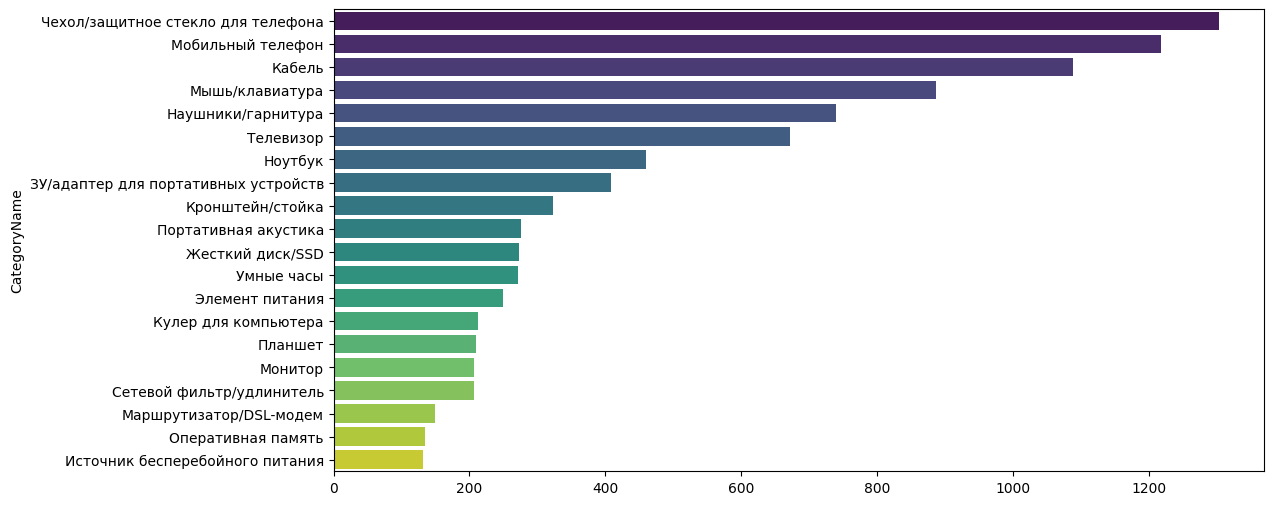

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


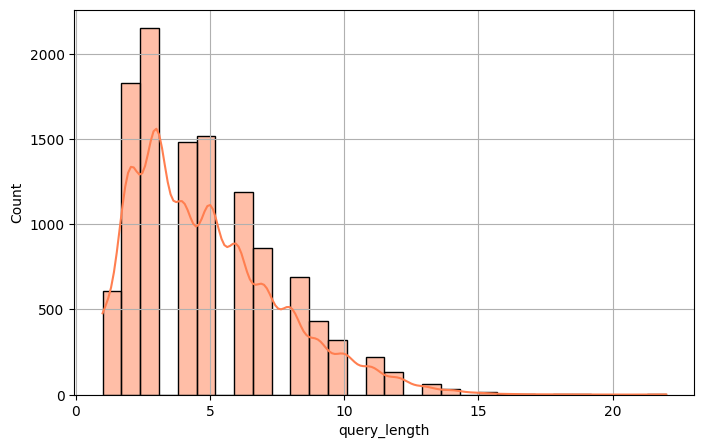

In [5]:
plt.figure(figsize=(12,6))
top_categories = train_df["CategoryName"].value_counts().head(20)
sns.barplot(x=top_categories.values, y=top_categories.index, palette = "viridis")
plt.show()

train_df["query_length"] = train_df["Query"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(train_df["query_length"], bins=30, kde=True, color="coral")
plt.grid(True)
plt.show()

* На первом графике видно, что есть категории с большим количеством запросов, а есть категории, где запросов очень мало. При таком раскладе модель будет хуже предсказывать редкие классы. Это я исправлю путем использования взвешенных моделей.
* На гистограмме видно, что в основном длина запроса короткая, поэтому для обучения моделей использую векторайзер tf-idf.

In [6]:
category_statistics = train_df["CategoryName"].value_counts()
print(round(category_statistics.mean(),2), category_statistics.median(),"\n", category_statistics.min(), category_statistics.max())

175.12 68.5 
 3 1304


Среднее кол-во примеров на категорию 175. Медиана отличается от среднего, поэтому распределение категорий неравномерное. Максимум и минимум сильно различаются. Все это говорит о дисбалансе классов, поэтому надо подобрать такие модели, которые эту проблему решают наиболее эффективно.

# 2. Обучение моделей

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score 
import re
import pandas as pd

Немного преобразую текст в столбце с запросами, чтобы модель обучалась лучше.

In [8]:
def cleaning(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)      
    text = re.sub(r"\d+", " ", text)         
    text = re.sub(r"\s+", " ", text)          
    return text.strip()

train_df["clean_query"] = train_df["Query"].apply(cleaning)
train_df.head()

,ID,CategoryID,Query,CategoryName,query_length,clean_query
0,1,1,edifier,Мультимедиа акустика,1,edifier
1,2,2,умная колонка яндекс станция лайт,Портативная акустика,5,умная колонка яндекс станция лайт
2,3,3,чехол iphone 14 pro,Чехол/защитное стекло для телефона,4,чехол iphone pro
3,4,4,zte,Мобильный телефон,1,zte
4,5,5,ноутбук huawei matebook b3-520 53012kfg,Ноутбук,5,ноутбук huawei matebook b kfg


In [9]:
X = train_df["clean_query"]
Y = train_df["CategoryID"]

X_train, X_value, y_train, y_value = train_test_split(X, Y, test_size = 0.2, stratify = Y, random_state = 42)

In [10]:
vectorizer = TfidfVectorizer(
    max_features=30000,        
    ngram_range=(1, 3),         
    sublinear_tf=True,          
    min_df=3,                 
    max_df=0.9                  
)
X_train_vect = vectorizer.fit_transform(X_train)
X_value_vect = vectorizer.transform(X_value)

Я попробую обучить 3 модели, которые лучше всего подходят для работы с текстом, и затем выберу ту модель, которая покажет самую высокую точность. 

In [11]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, solver='saga'),
    "Random Forest": RandomForestClassifier(class_weight='balanced', n_estimators=1000, random_state=42)
}

In [12]:
results = {}

for name, model in models.items():
    model.fit(X_train_vect, y_train)
    preds = model.predict(X_value_vect)
    acc = accuracy_score(y_value, preds) 
    results[name] = (acc, model)
    print(f"{name} Accuracy: {acc:.4f}")

Naive Bayes Accuracy: 0.8274


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression Accuracy: 0.8603
Random Forest Accuracy: 0.8949


In [13]:
best_model_name = max(results, key=lambda x: results[x][0]) 
best_model = results[best_model_name][1]
print(f"\n Лучшая модель: {best_model_name}")


 Лучшая модель: Random Forest


Самую высокую точность показала модель RandomForestClassifier, поэтому для прогнозирования на тестовых данных буду использовать именно её.

# 3. Предсказание на тестовых данных

In [14]:
test_df["clean_query"] = test_df["Query"].apply(cleaning)
X_test_vect = vectorizer.transform(test_df["clean_query"])
test_preds = best_model.predict(X_test_vect)

In [15]:
result_df = pd.DataFrame({
    "ID": test_df["ID"], 
    "CategoryID": test_preds      
})
result_df.head()

,ID,CategoryID
0,0,0
1,15,4
2,21,4
3,22,14
4,24,3


In [16]:
result_df.to_csv("submission.csv", index=False)

# 4. Дополнения и улучшения

In [17]:
import lightgbm as lgb
from catboost import CatBoostClassifier
from scipy.stats import mode